# Занятие 5: Регрессия и основы нейросетей

На прошлом занятии мы делали классификацию — разделяли объекты на группы. Сегодня мы посмотрим на другую задачу — регрессию: когда надо предсказать число — цену, балл, температуру. После этого перейдём к нейросетям: их идея проста — собрать много маленьких «простых моделей» (нейронов) в одну большую, чтобы научиться распознавать сложные закономерности, например — цифры на картинке.

## 1. Классификация vs регрессия

| Параметр          | Классификация           | Регрессия       |
| ----------------- | ----------------------- | --------------- |
| Что предсказываем | Категорию (класс)       | Число           |
| Примеры           | Выжил/нет, спам/не спам | Цена дома, рост |
| Основные метрики  | Accuracy, F1            | MSE, MAE, R²    |

*Titanic был классификацией, сегодня — прогнозирование чисел.*

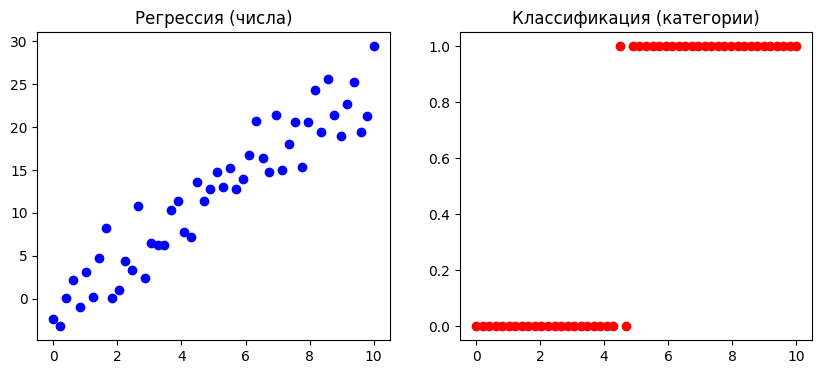

In [126]:
# Простая демонстрация различий
import numpy as np
import matplotlib.pyplot as plt

X = np.linspace(0, 10, 50)                  # 50 точек от 0 до 10
y_reg = 2.5 * X + np.random.randn(50) * 3   # линейная зависимость с шумом
y_cls = (y_reg > np.mean(y_reg)).astype(int)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(X, y_reg, color='blue')
axs[0].set_title("Регрессия (числа)")
axs[1].scatter(X, y_cls, color='red')
axs[1].set_title("Классификация (категории)")
plt.show()

## 2. Регрессия и метрики

* Цель: предсказать непрерывную величину $(y \in \mathbb{R})$.
* Примеры: цена дома, балл ученика, температура.
* Базовая модель: линейная регрессия — $(y = w_1 x_1 + w_2 x_2 + ... + b)$.
* Метрики:

  * MSE (Mean Squared Error) — средний квадрат ошибки $(\frac{1}{n}\sum (y_i-\hat y_i)^2)$. Чувствителен к большим ошибкам.
  * MAE (Mean Absolute Error) — средняя абсолютная ошибка $(\frac{1}{n}\sum |y_i-\hat y_i|)$. Интерпретируем лучше (в тех же единицах, что и целевая).
  * R² — доля объяснённой дисперсии. $(R^2=1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2})$. Ближе к 1 — лучше.

## 3. Линейная регрессия 

*Начнём с самой простой формы — линейной зависимости между X и Y.*

MSE: 4.289497789073182
MAE: 1.6559442969682743
R²: 0.9487169644292098


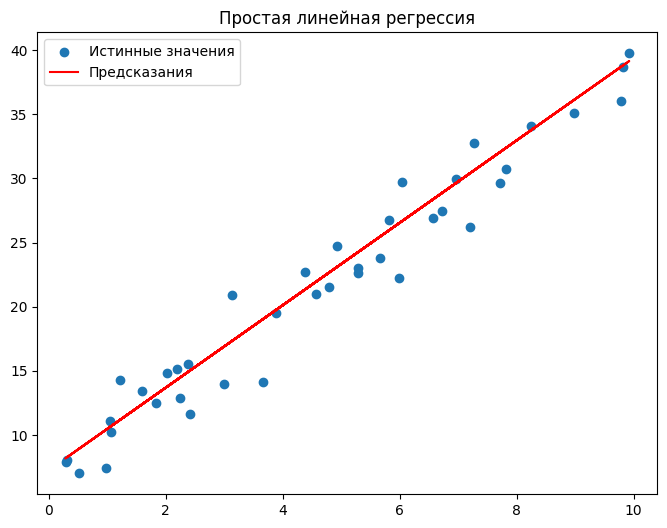

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# данные
X = np.random.rand(200, 1) * 10                 # 200 случайных чисел от 0 до 10
y = 3.2 * X + 7 + np.random.randn(200, 1) * 2   # y = 3.2x + 7 + шум

# разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random_state=42 - для воспроизводимости результатов
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# метрики
print("MSE:", mean_squared_error(y_test, y_pred))   # Средняя квадратичная ошибка
print("MAE:", mean_absolute_error(y_test, y_pred))  # Средняя абсолютная ошибка 
print("R²:", r2_score(y_test, y_pred))              # Коэффициент детерминации

# график
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, label='Истинные значения')
plt.plot(X_test, y_pred, color='r', label='Предсказания')
plt.legend()
plt.title("Простая линейная регрессия")
plt.show()

*Задание:*

* Измени коэффициенты при генерации данных (10 → 0 → 100; 3.2 → 5, 7 → 0).

* Посмотри, как изменилась линия и R².

## 4. Многомерная регрессия (student_scores)

In [128]:
import pandas as pd

data = {
    'hours': [1,2,3,4,5,6,7,8,9,10],
    'attendance': [60,65,70,75,80,85,90,95,97,100],
    'previous_grade': [50,55,60,65,70,75,80,85,88,90],
    'final_score': [52,56,61,66,71,77,82,87,90,94]
}
df = pd.DataFrame(data)

X = df[['hours', 'attendance', 'previous_grade']]
y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.8066666666666554
R²: 0.9945383512544804


*Задание:*

* Добавь новый признак “мотивация” ('motivation' : [3,4,5,5,6,7,8,8,9,10]), проверь, вырос ли R².

## 5. Нейросеть

* **Нейрон** (в математике) — вычисляет $(z = w\cdot x + b)$, потом применяет функцию активации $(a = \sigma(z))$.
* **Слой** — набор нейронов, принимает вектор, выдаёт вектор.
* **Сеть** = слои, соединённые последовательно (или иначе).
* **Обучение** — подобрать веса $(w)$ и смещения $(b)$, чтобы минимизировать loss на примерах.

Нейросеть — это просто набор умножений (веса) и сумм (смещения) + нелинейность (активация через `ReLU`, `sigmoid`, `tanh`), обучаемый на примерах.

![](https://www.dmitrymakarov.ru/wp-content/uploads/2021/10/mnist-nn-1024x636.png)

### ReLU

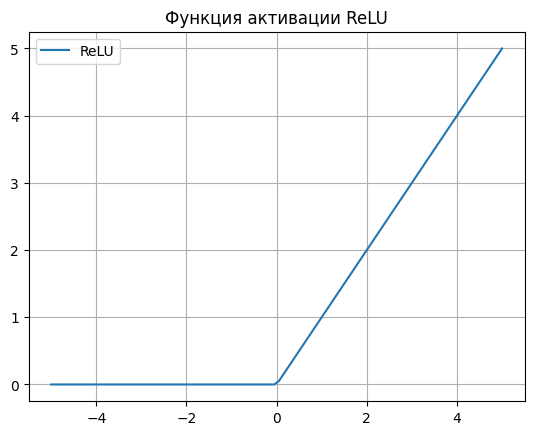

In [129]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-5, 5, 100)
relu = np.maximum(0, x)
plt.plot(x, relu, label='ReLU')
plt.title("Функция активации ReLU")
plt.legend()
plt.grid()
plt.show()

### Сигмоида

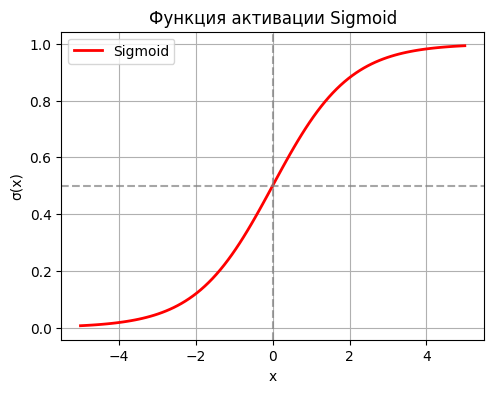

In [130]:
x = np.linspace(-5, 5, 100)
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, sigmoid, label='Sigmoid', color='red', linewidth=2)
plt.title("Функция активации Sigmoid")
plt.xlabel('x')
plt.ylabel('σ(x)')
plt.legend()
plt.grid(True)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

### Гиперболический тангенс

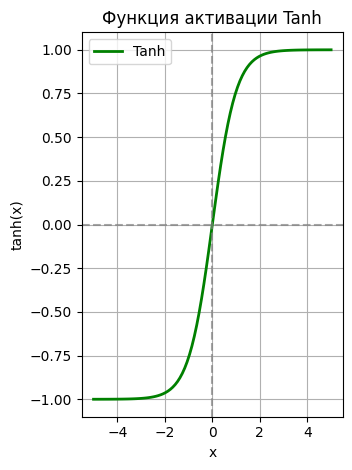

In [131]:
plt.subplot(1, 2, 2)
tanh = np.tanh(x)
plt.plot(x, tanh, label='Tanh', color='green', linewidth=2)
plt.title("Функция активации Tanh")
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 5.1 Что такое вес и смещение (bias)

* **Вес (weight)** — множитель для входа. Если вход важен — вес большой по абсолютной величине; если не важен — близок к нулю.
* **Смещение (bias)** — это свободный параметр, который позволяет нейрону иметь ненулевой отклик даже при нулевых входах.

Математически: нейрон делает $(z = \sum_i w_i x_i + b)$ → активация $(\sigma(z))$.

## 5.2 Зачем нужна функция активации

* Без активации каждый слой — просто линейное преобразование. Последовательность линейных слоёв — всё равно линейное преобразование: добавление слоёв не даёт мощи.
* **Активация** — даёт **нелинейность**, благодаря ей сеть может аппроксимировать сложные функции.
* Популярные функции:

  * `ReLU(x)=max(0,x)` — простая, быстрая, решает проблему «затухающего градиента» частично; часто используется в скрытых слоях.
  * `sigmoid(x)=1/(1+e^{-x})` — выдаёт число в (0,1), подходит для бинарных выходов (ранее широко использовалась, сейчас реже в скрытых слоях).
  * `tanh(x)` — похожа на sigmoid, выдаёт в (-1,1).
  * `softmax` — используется в последнем слое для многоклассовой классификации; нормирует выходы в вероятности. Преобразует вектор в распределение вероятностей,сумма выходов всегда равна 1

Активация — это нелинейный фильтр, который помогает сети учиться не только прямым зависимостям, но и изгибам/поворотам в пространстве признаков.

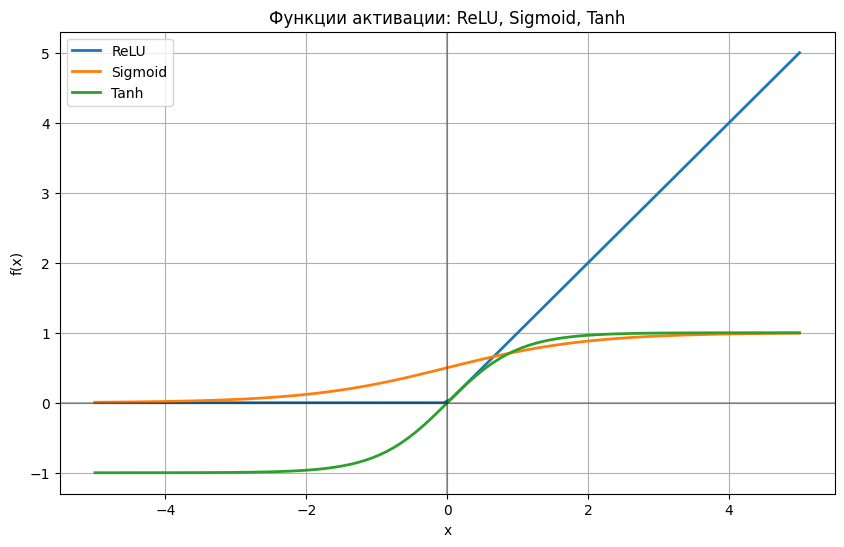

In [132]:
plt.figure(figsize=(10, 6))

plt.plot(x, relu, label='ReLU', linewidth=2)
plt.plot(x, sigmoid, label='Sigmoid', linewidth=2)
plt.plot(x, tanh, label='Tanh', linewidth=2)

plt.title("Функции активации: ReLU, Sigmoid, Tanh")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.show()

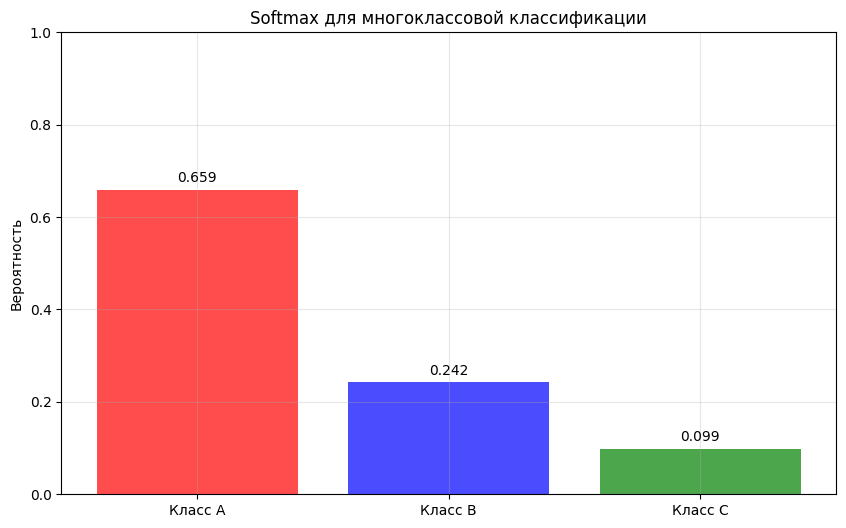

Логиты: [2.  1.  0.1]
Softmax вероятности: [0.65900114 0.24243297 0.09856589]
Сумма вероятностей: 1.0


In [133]:
plt.figure(figsize=(10, 6))

logits = np.array([2.0, 1.0, 0.1])
softmax_output = np.exp(logits) / np.sum(np.exp(logits))

classes = ['Класс A', 'Класс B', 'Класс C']
colors = ['red', 'blue', 'green']

plt.bar(classes, softmax_output, color=colors, alpha=0.7)
plt.title("Softmax для многоклассовой классификации")
plt.ylabel("Вероятность")
plt.ylim(0, 1)

for i, v in enumerate(softmax_output):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3)
plt.show()

print("Логиты:", logits)
print("Softmax вероятности:", softmax_output)
print("Сумма вероятностей:", np.sum(softmax_output))

### 5.3 Простым языком)

*Хотим узнать друга в толпе людей*

#### Нейрон — маленький мозг

`ВХОДЫ (глаза) → [ НЕЙРОН ] → ВЫХОД (узнал/не узнал)`

**Веса** — это «важность» каждой детали:
- Волосы: вес 0.8 (очень важны)
- Очки: вес 0.6 (важны)  
- Рост: вес 0.3 (не очень важен)

#### Как нейрон работает:

1. **Собираем информацию**: 
   - Видим волосы (1 = есть), очки (1 = есть), рост (0.7 = высокий)
   - Умножаем на веса: `1×0.8 + 1×0.6 + 0.7×0.3 = 1.61`

2. **Функция активации — это "принятие решения"**:

```python
# ReLU — простой порог
if сумма > 0: 
    return "ДА, ЭТО ОН!"
else:
    return "НЕТ, НЕ ОН"

# Сигмоида — неуверенный ответ
"НАВЕРНОЕ ЭТО ОН... (70% уверенности)"

# Softmax — выбор из нескольких
"ЭТО ВАСЯ (60%), А НЕ ПЕТЯ (30%) ИЛИ КОЛЯ (10%)"
```

#### Функции активации — это разные характеры:

- **ReLU** — решительный: "Да или нет!"
- **Sigmoid** — осторожный: "Возможно... может быть..."
- **Tanh** — эмоциональный: "Точно ДА! или точно НЕТ!"
- **Softmax** — мудрый: "Это Вася, но может быть Петя"

#### Всё вместе:

`[Глаза видят] → [Веса: что важно] → [Суммируем] → [Функция активации принимает решение] → [Ответ]`

**Обучение** — это когда нейрон учится правильно подбирать веса:
- Если ошибся → корректирует веса
- Если угадал → укрепляет веса

## 6. Первая сеть на Keras

/usr/lib/python3/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

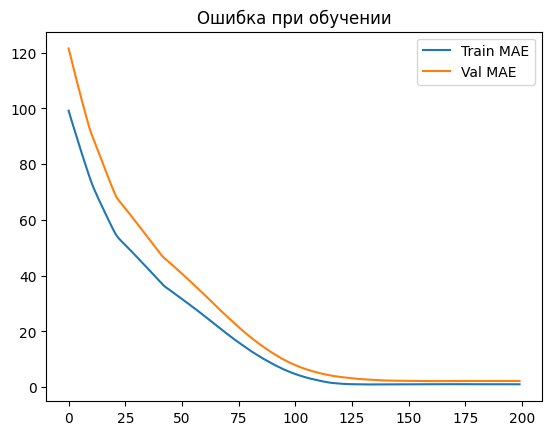

In [134]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(3,)), # 1-й скрытый слой
    layers.Dense(8, activation='relu'),                    # 2-й скрытый слой
    layers.Dense(1)                                        # выходной слой
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# обучение
history = model.fit(X_train, y_train, epochs=200, batch_size=2, validation_split=0.2, verbose=0)

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Ошибка при обучении')
plt.legend()
plt.show()

## 6.1 Почему loss уменьшается при обучении

* Мы измеряем ошибку (loss) на обучающей выборке: например `mse`.
* Алгоритм обучения (обычно — градиентный спуск или его варианты: Adam, RMSprop и т.д.) вычисляет градиент — направление, в котором loss убывает.
* Затем шаг за шагом меняем веса: $(w \leftarrow w - \eta \cdot \nabla_w L)$, где $(\eta)$ — learning rate.
* В результате — loss на train обычно уменьшается:

  * На малых эпохах сеть учится общим закономерностям — loss падает быстро.
  * Позже может убывать медленнее; при переобучении train loss продолжает падать, а val loss начинает расти.
* Почему не всегда монотонно: стохастичность (mini-batches), шум, слишком большой $(\eta)$ — могут давать «прыжки».

Мы даём сети пример → она чуть корректирует веса → ошибка уменьшилась → повторяем.

## 6.2 Что такое валидация и зачем она нужна

* **Train** — данные, на которых мы обучаем модель (корректируем веса).
* **Validation** — отдельная часть обучающего набора (или отдельный набор), которую мы используем **во время** обучения, чтобы смотреть, как модель *обобщается* на новые данные (не участвующие в обновлении весов).
* **Test** — финальный набор, для окончательной оценки (не использовать для обучения моделей).
* **Зачем валидировать?**

  * Чтобы увидеть переобучение (overfitting): train loss падает, а val loss растёт → модель запомнила шум, а не закономерности.
  * Для выбора гиперпараметров (число слоёв, нейронов, learning rate).
  * Для ранней остановки (early stopping): остановить обучение, когда val loss не улучшается — это предотвращает переобучение.
* Правило: **никогда** не подбирать архитектуру/гиперпараметры по test set.

Валидация — это проверка: учится ли модель общему, а не только запоминанию.

## 7. MNIST

Теперь давайте применим нейросеть не к трём признакам, а к 784 (28×28) — каждому пикселю изображения цифры.
Это задача классификации изображений.